In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("jul-2025-individual-call-records.csv")

In [4]:
df1 = pd.read_csv("jun-2025-individual-call-records.csv")

In [5]:
df2= pd.read_csv("Aug-2025-individual-call-records.csv")

In [6]:
df = pd.concat([df1, df, df2], ignore_index=True)

In [7]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,80548049535,2025-06-01 16:44,Outbound,00:00:00,NaN,Kevin Nuesi
1,80547821455,2025-06-01 16:45,Outbound,00:00:00,NaN,Kevin Nuesi
2,80550594447,2025-06-01 20:15,Inbound,00:00:00,NaN,NaN
3,80566407069,2025-06-02 09:22,NaN,NaN,NaN,Robin Stoehr
4,80569306473,2025-06-02 09:52,NaN,NaN,NaN,Robin Stoehr
...,...,...,...,...,...,...
41165,87659644588,2025-08-30 16:16,Inbound,00:00:00,NaN,NaN
41166,87665075207,2025-08-30 16:37,Outbound,00:00:07,NaN,Sam Steindorf
41167,87698385206,2025-08-31 15:57,Inbound,00:00:00,NaN,NaN
41168,87698965351,2025-08-31 16:42,Inbound,00:00:00,NaN,NaN


In [8]:
df1 = df.drop(columns = ['hs_call_outcome', 'Record ID'])

In [9]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 41170 entries, 0 to 41169
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         41170 non-null  str  
 1   Call direction        37631 non-null  str  
 2   Call duration         37780 non-null  str  
 3   Activity assigned to  38656 non-null  str  
dtypes: str(4)
memory usage: 2.9 MB


In [10]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# Call Count per day

In [12]:
df2 = df1.copy()

In [13]:
df2['date'] = df2['Activity date'].dt.date

In [14]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN,2025-06-01
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,2025-06-02
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,2025-06-02


In [15]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [16]:
daily_calls.head()

,date,call_count
0,2025-06-01,3
1,2025-06-02,458
2,2025-06-03,578
3,2025-06-04,692
4,2025-06-05,398


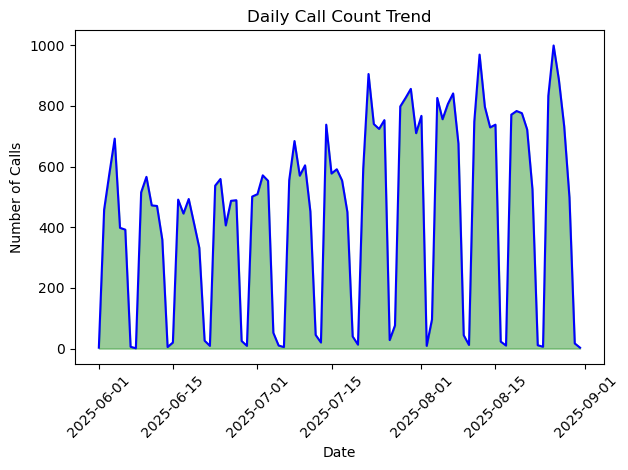

In [17]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color = 'blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='green', alpha=0.4)

plt.title("Daily Call Count Trend")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr


# Count of Call in Weekdays

In [20]:
df1['day'] = df1['Activity date'].dt.day_name()

In [21]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi,Sunday
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi,Sunday
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN,Sunday
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,Monday
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,Monday


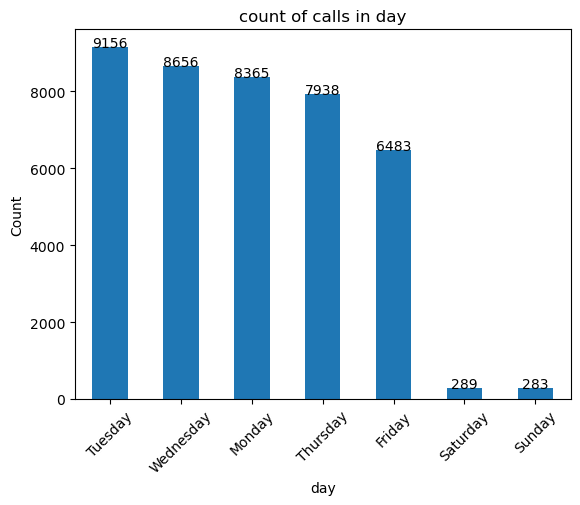

In [22]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i,v+1, str(v), ha= "center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

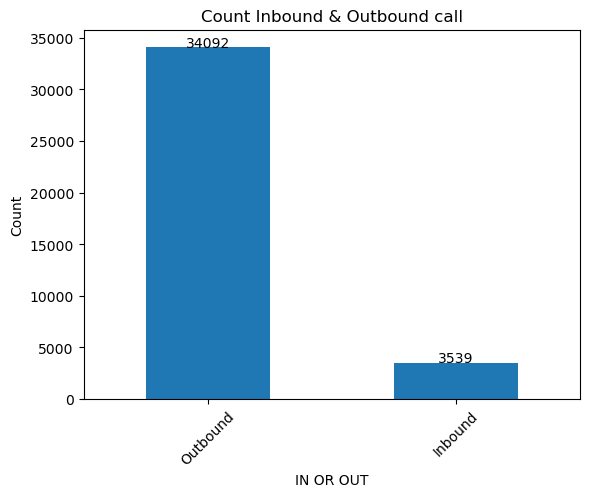

In [24]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [26]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

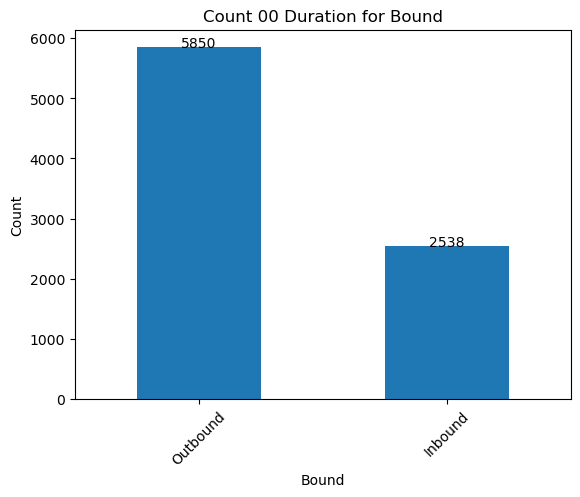

In [27]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration Null but have Call direction

In [29]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
1964,2025-06-05 15:30:00,Outbound,NaN,Jinky Rance,Thursday
3192,2025-06-10 13:58:00,Outbound,NaN,Robin Stoehr,Tuesday
4229,2025-06-12 13:59:00,Outbound,NaN,Keith Antonio,Thursday
6424,2025-06-19 12:03:00,Inbound,NaN,Robin Stoehr,Thursday
6935,2025-06-20 14:30:00,Outbound,NaN,Christian Banks,Friday
6937,2025-06-20 14:32:00,Outbound,NaN,Christian Banks,Friday
6939,2025-06-20 14:34:00,Outbound,NaN,Christian Banks,Friday
6943,2025-06-20 14:44:00,Outbound,NaN,Christian Banks,Friday
7368,2025-06-23 15:05:00,Outbound,NaN,Robin Stoehr,Monday
9832,2025-06-30 15:31:00,Outbound,NaN,Christian Banks,Monday


In [30]:
df4 = df1.copy()

In [31]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi,Sunday
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi,Sunday
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN,Sunday
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,Monday
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,Monday


In [32]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [33]:
(df4['Call duration'] == 0).sum()

8388

In [34]:
df4['Call duration'].isnull().sum()

3390

In [35]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 41170 entries, 0 to 41169
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         41170 non-null  datetime64[us]
 1   Call direction        37631 non-null  str           
 2   Call duration         37780 non-null  float64       
 3   Activity assigned to  38656 non-null  str           
 4   day                   41170 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 2.6 MB


In [36]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [37]:
df4 = df4.dropna(subset = ['Call direction'])

In [38]:
df4['Call duration'].isnull().sum()

0

In [39]:
df4['Call direction'].isnull().sum()

0

In [40]:
(df4['Call duration'] == 0).sum()

8424

In [41]:
df4.info()

<class 'pandas.DataFrame'>
Index: 37631 entries, 0 to 41169
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         37631 non-null  datetime64[us]
 1   Call direction        37631 non-null  str           
 2   Call duration         37631 non-null  float64       
 3   Activity assigned to  35154 non-null  str           
 4   day                   37631 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 2.7 MB


# Working Call Assigner

In [43]:
df1['Activity assigned to'].nunique()

34

In [44]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[       'Kevin Nuesi',                  nan,       'Robin Stoehr',
     'Cameron Dudley',    'Christian Banks',       'David Valdez',
       'Cameron Byrd',     'Boston Hoppman',      'Keith Antonio',
        'Tyler Smith',        'Jinky Rance',      'Sam Steindorf',
       'Jerome Joyce',             'Abhi C',      'Garrett Evans',
   'Chrystel Manabat',         'Tyler Jury',        'Jon Karimov',
    'Blake Roudebush',     'David Banister',  'Brittany Digiulio',
        'Paol Guzman',    'Adonis Baybayan',      'Oliver Martin',
     'Nick Rothacher',       'Bill Goodwin',          'Juan Calo',
       'Jibran Ahmad',      'Marvin Laguna',       'Kendra Lilly',
     'Tommy Canfield', 'Jonathan Hernandez',        'Zach Drissi',
    'Taylor Shuppert',     'Andrew Stewart']
Length: 35, dtype: str

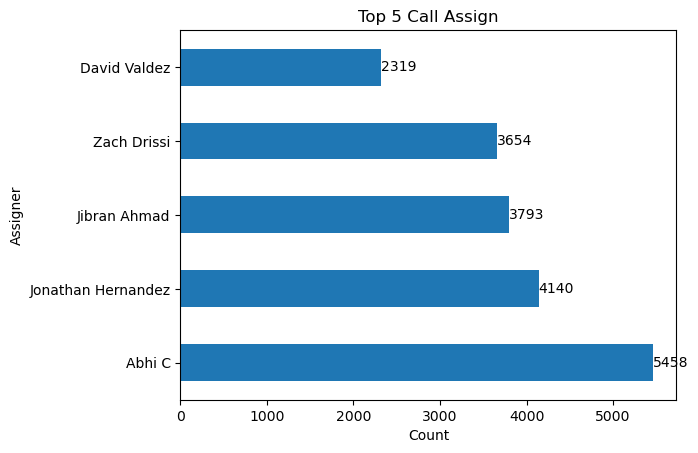

In [45]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [47]:
df4['Call duration'].max()

100.65

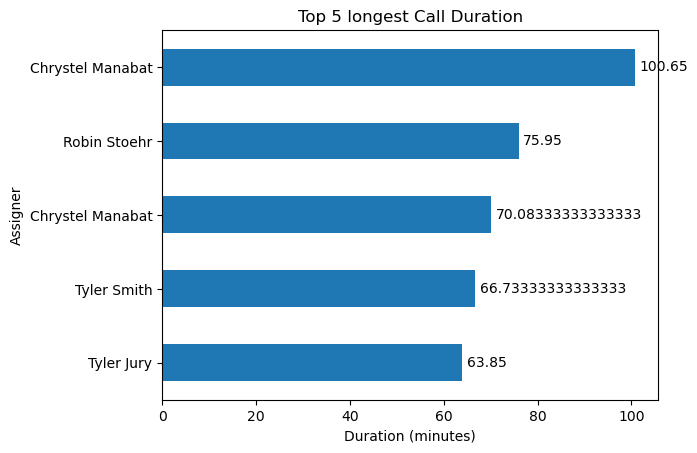

In [48]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Week days Call Volume

In [50]:
df3=df1.copy()

In [51]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [52]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [53]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

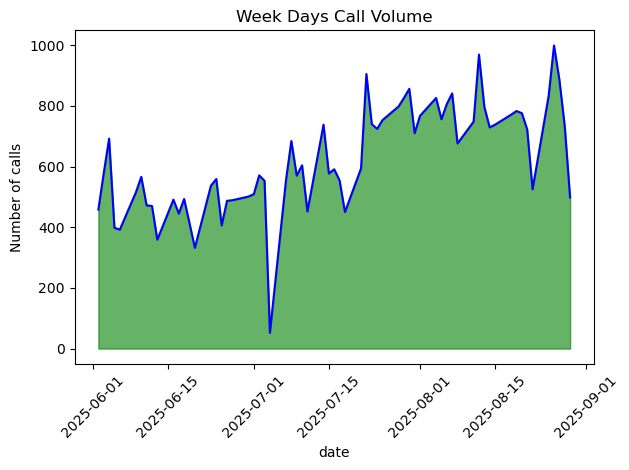

In [54]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [56]:
df5=df4.copy()

In [57]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [58]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-06-01 16:44:00,Outbound,0.000000,Kevin Nuesi,Sunday
1,2025-06-01 16:45:00,Outbound,0.000000,Kevin Nuesi,Sunday
2,2025-06-01 20:15:00,Inbound,0.000000,NaN,Sunday
2521,2025-06-07 09:07:00,Outbound,0.316667,Blake Roudebush,Saturday
2522,2025-06-07 10:18:00,Inbound,0.000000,NaN,Saturday


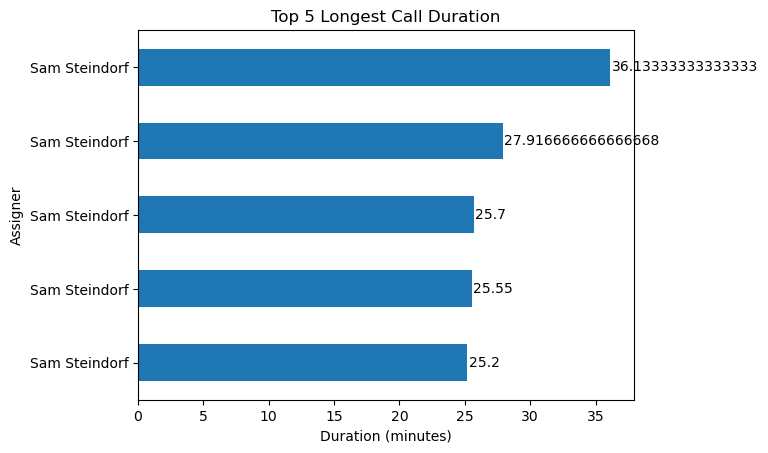

In [59]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top5 Weekend Call Assigner

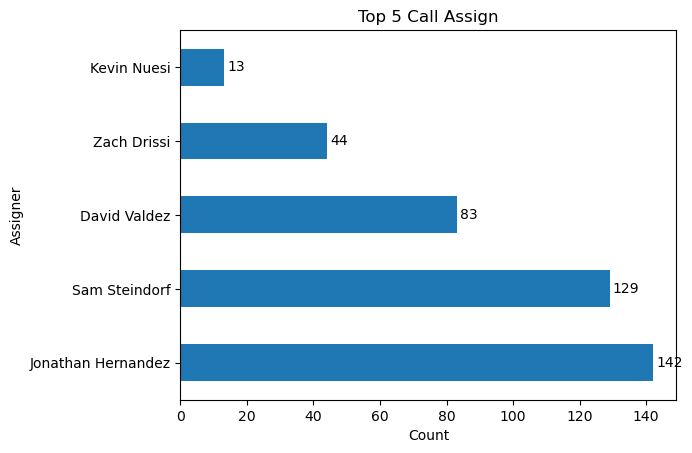

In [61]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Monthly Call Count

In [63]:
df6 = df3.copy()

In [64]:
df6['month'] = df6['Activity date'].dt.month_name()

In [65]:
df6.head()

,Activity date,Call direction,Call duration,Activity assigned to,day,month
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,Monday,June
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,Monday,June
5,2025-06-02 09:56:00,NaN,NaN,Robin Stoehr,Monday,June
6,2025-06-02 09:59:00,NaN,NaN,Robin Stoehr,Monday,June
7,2025-06-02 10:00:00,Outbound,00:00:06,Cameron Dudley,Monday,June


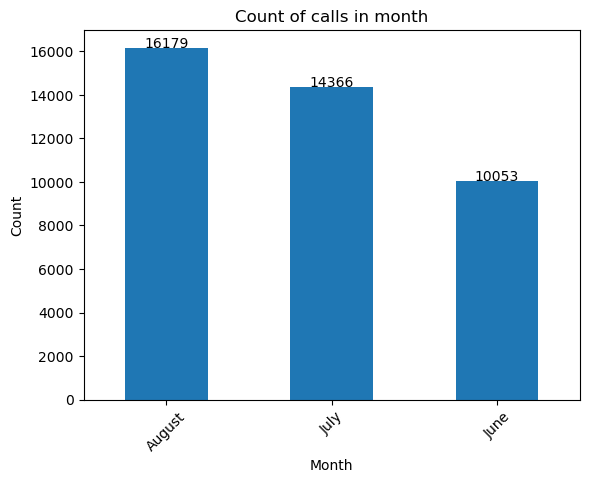

In [66]:
month_counts = df6["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls in month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Average Call duration

In [68]:
df4["Call duration"].mean()

2.1248518508676355

In [69]:
df4["Call duration"].median()

0.1

# Without Call Assigner Calls

In [71]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

In [72]:
no_assigner_calls.info()

<class 'pandas.DataFrame'>
Index: 2411 entries, 33 to 41149
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         2411 non-null   datetime64[us]
 1   Call direction        2375 non-null   str           
 2   Call duration         2410 non-null   str           
 3   Activity assigned to  0 non-null      str           
 4   day                   2411 non-null   str           
 5   month                 2411 non-null   str           
dtypes: datetime64[us](1), str(5)
memory usage: 196.6 KB


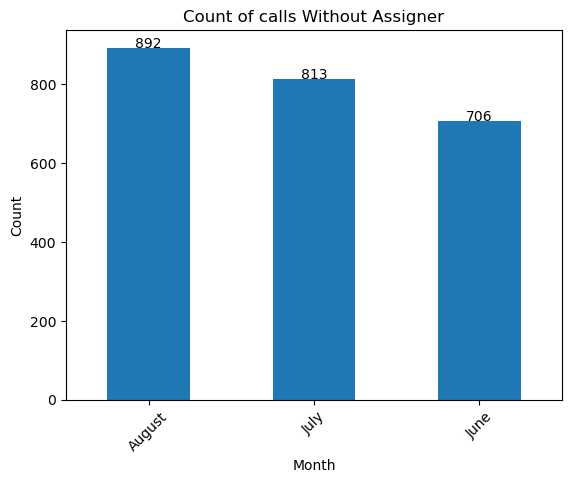

In [73]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top5 peak Call date

In [75]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN,2025-06-01
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,2025-06-02
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,2025-06-02


In [76]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [77]:
top5 = daily_calls.sort_values(ascending=False).head(5)

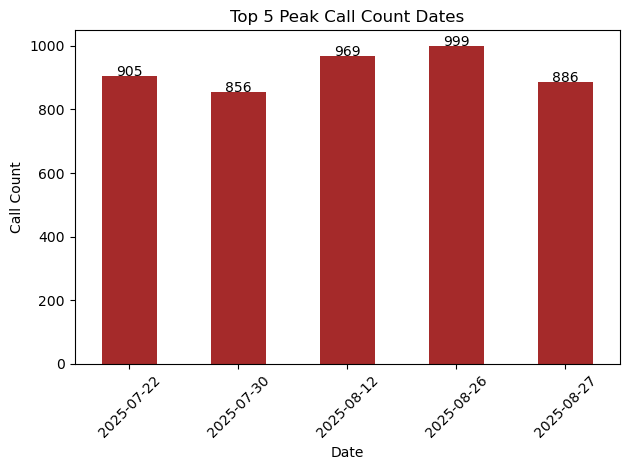

In [78]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count Dates")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()